In [4]:
print("Student Performance Prediction Project")

Student Performance Prediction Project


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


# Student Performance Prediction & Analytics System

## Project Objective

The objective of this project is to analyze student-related factors
and build a machine learning model that predicts academic performance.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Streamlit

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import Required Libraries

## 2. Load the Dataset

In [7]:
df = pd.read_csv('/content/student-mat.csv', sep=';')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 395
Number of columns: 33


In [10]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [11]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [12]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [13]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [14]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [15]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [16]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [17]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [18]:
df['G3'].describe()

,G3
count,395.000000
mean,10.415190
std,4.581443
min,0.000000
25%,8.000000
50%,11.000000
75%,14.000000
max,20.000000


In [19]:
df['G3'].value_counts().sort_index()

,count
G3,
0,38
4,1
5,7
6,15
7,9
8,32
9,28
10,56
11,47


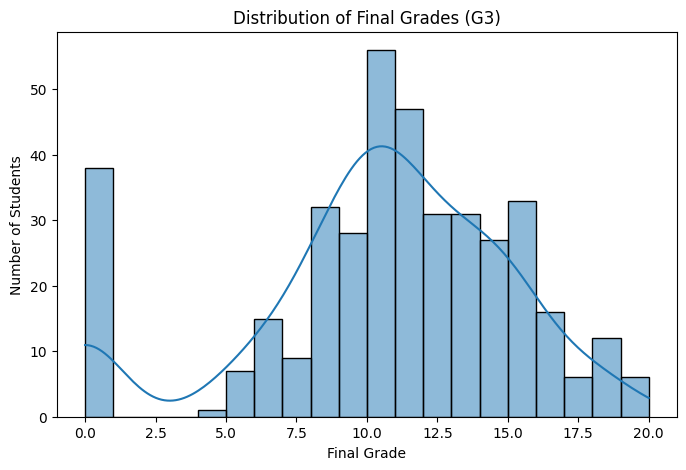

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(df['G3'], bins=20, kde=True)

plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')

plt.show()

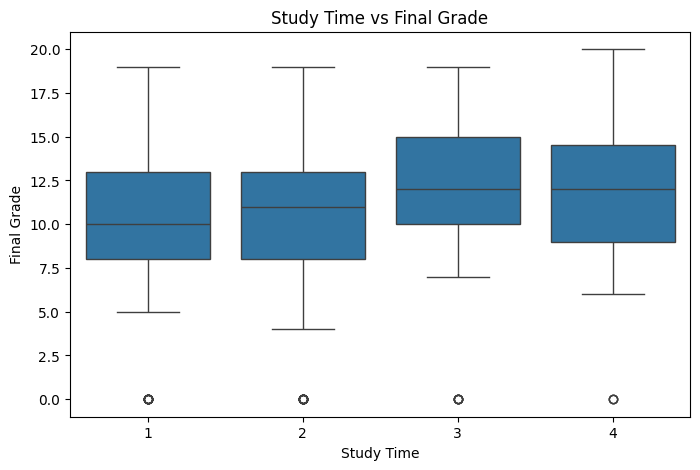

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='studytime', y='G3', data=df)

plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')

plt.show()

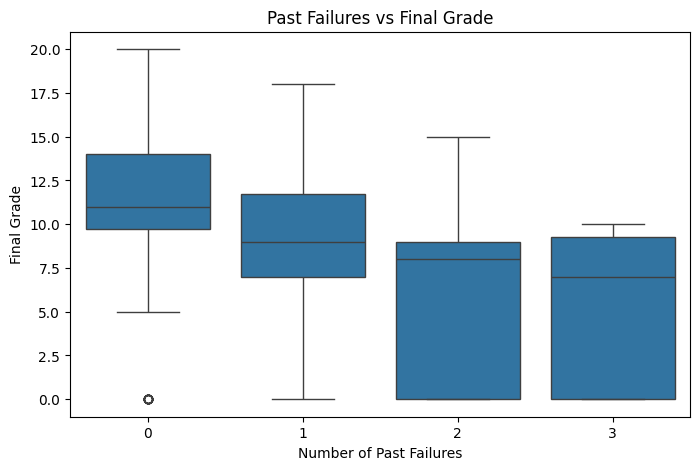

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='failures', y='G3', data=df)

plt.title('Past Failures vs Final Grade')
plt.xlabel('Number of Past Failures')
plt.ylabel('Final Grade')

plt.show()

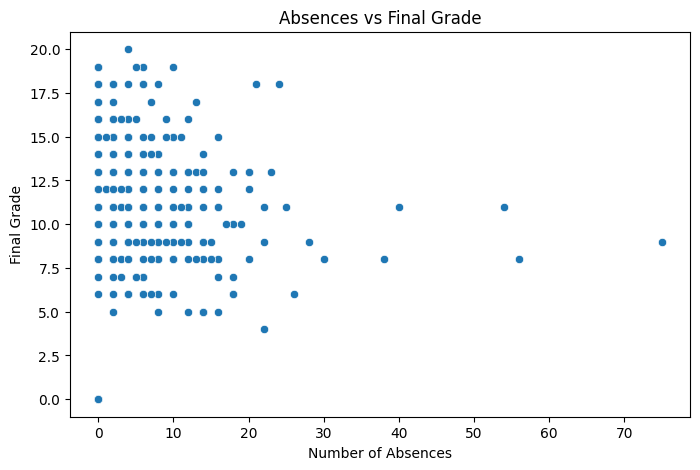

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x='absences', y='G3', data=df)

plt.title('Absences vs Final Grade')
plt.xlabel('Number of Absences')
plt.ylabel('Final Grade')

plt.show()

In [24]:
numeric_df = df.select_dtypes(include='number')

correlation = numeric_df.corr()

correlation['G3'].sort_values(ascending=False)

,G3
G3,1.000000
G2,0.904868
G1,0.801468
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307
Walc,-0.051939


In [25]:
correlation_without_grades = correlation['G3'].drop(['G1', 'G2', 'G3'])

correlation_without_grades.sort_values(ascending=False)

,G3
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307
Walc,-0.051939
Dalc,-0.054660
health,-0.061335
traveltime,-0.117142


In [26]:
print("Correlation between absences and G3:",
      df['absences'].corr(df['G3']))

print("Correlation between failures and G3:",
      df['failures'].corr(df['G3']))

print("Correlation between studytime and G3:",
      df['studytime'].corr(df['G3']))

Correlation between absences and G3: 0.03424731615006931
Correlation between failures and G3: -0.3604149404616497
Correlation between studytime and G3: 0.09781968965319626


In [27]:
# Correlation with final grade, excluding previous grades
feature_correlations = correlation['G3'].drop(['G1', 'G2', 'G3'])

print("Correlation of features with final grade:")
print(feature_correlations.sort_values(ascending=False))

Correlation of features with final grade:
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


In [29]:
# Define input features
X = df.drop(columns=['G1', 'G2', 'G3'])

# Define target
y = df['G3']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 30)
y shape: (395,)


In [30]:
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,4
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,2
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,4


In [31]:
y.head()

,G3
0,6
1,6
2,10
3,15
4,10


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

print("Preprocessing libraries imported successfully!")

Preprocessing libraries imported successfully!


In [33]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [34]:
print("Number of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Number of categorical features: 17
Number of numerical features: 13


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', 'passthrough', numerical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 316
Testing samples: 79


In [37]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

print("Linear Regression pipeline created!")

Linear Regression pipeline created!


In [38]:
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [39]:
y_pred = linear_model.predict(X_test)

print("First 10 actual grades:")
print(y_test.head(10).values)

print("\nFirst 10 predicted grades:")
print(y_pred[:10])

First 10 actual grades:
[10 12  5 10  9 13 18  6  0 14]

First 10 predicted grades:
[ 1.88508025  7.45339224  8.30868805 11.55112413 10.20284528  9.43314825
 13.21126069 12.69040139 10.26673682 12.34152834]


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

Linear Regression Results
-------------------------
MAE : 3.395
RMSE: 4.196
R²  : 0.141


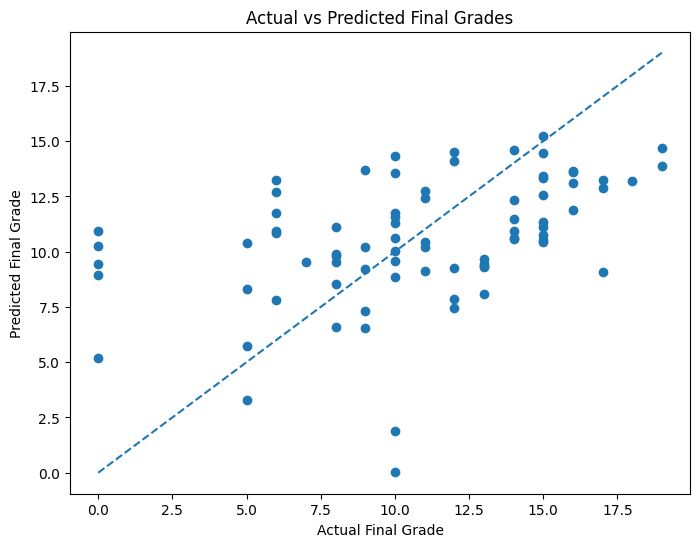

In [41]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Final Grades")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

In [42]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]
)

print("Random Forest pipeline created!")

Random Forest pipeline created!


In [43]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [44]:
rf_pred = rf_model.predict(X_test)

print("First 10 actual grades:")
print(y_test.head(10).values)

print("\nFirst 10 Random Forest predications:")
print(np.round(rf_pred[:10],2))



First 10 actual grades:
[10 12  5 10  9 13 18  6  0 14]

First 10 Random Forest predications:
[ 9.74  9.41 10.22 12.18 10.08  9.2  14.53 11.33 10.5  12.41]


In [45]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("--------------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

Random Forest Results
--------------------
MAE : 2.986
RMSE: 3.765
R²  : 0.309


In [46]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R2 Score': [r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.395261,4.195681,0.141492
1,Random Forest,2.986076,3.765423,0.308541
